In [501]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [502]:
df=pd.read_excel('Telco_customer_churn.xlsx')

In [503]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [504]:
df.shape

(7043, 33)

In [505]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [506]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

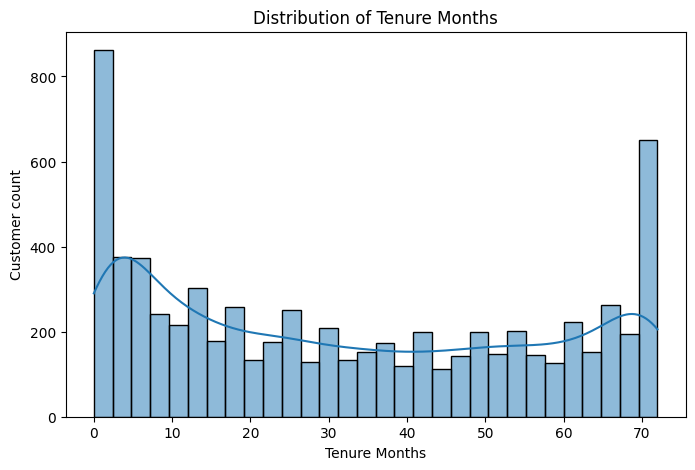

In [507]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months')
plt.show()

In [508]:
df['Tenure Months'].max()


np.int64(72)

In [509]:
df['Tenure Months'].min()

np.int64(0)

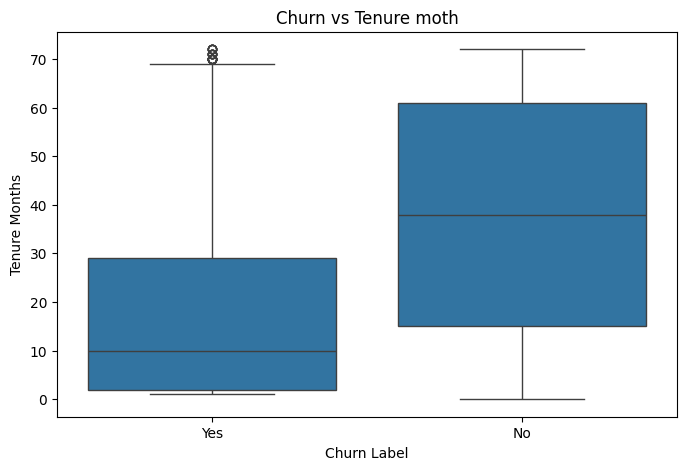

In [510]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure moth')
plt.show()

In [511]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

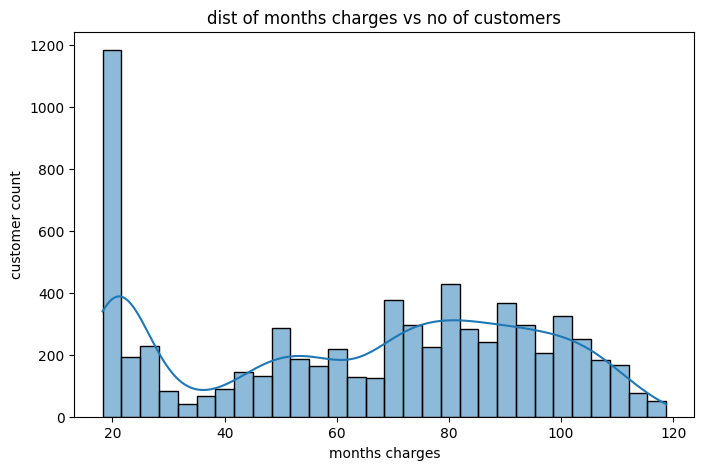

In [512]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('months charges')
plt.ylabel('customer count')
plt.title('dist of months charges vs no of customers')
plt.show()

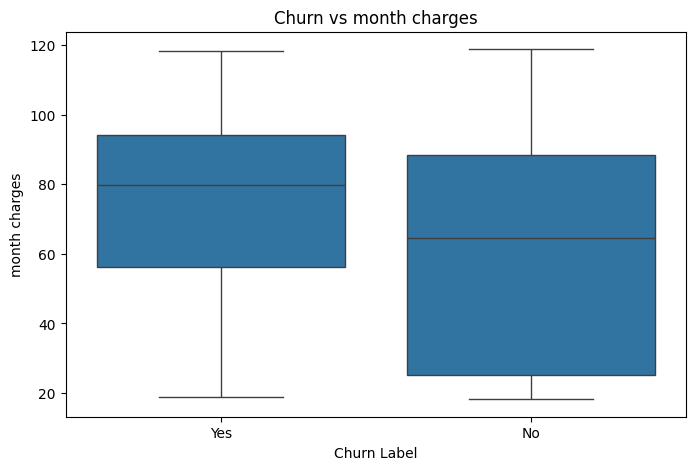

In [513]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.xlabel('Churn Label')
plt.ylabel('month charges')
plt.title('Churn vs month charges')
plt.show()

In [514]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    25.100
0.50    64.425
0.75    88.400
Name: Monthly Charges, dtype: float64

In [515]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    56.15
0.50    79.65
0.75    94.20
Name: Monthly Charges, dtype: float64

In [516]:
df['Monthly Charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

In [517]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    35.50
0.50    70.35
0.75    89.85
Name: Monthly Charges, dtype: float64

In [518]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

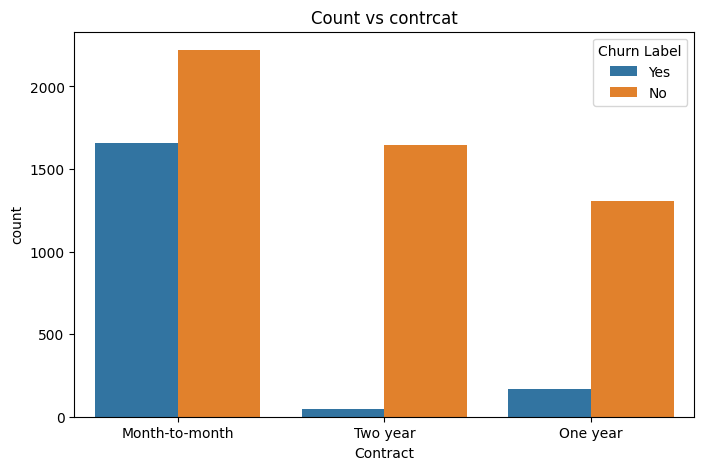

In [519]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('Contract')
plt.ylabel('count')
plt.title('Count vs contrcat')
plt.show()

In [520]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

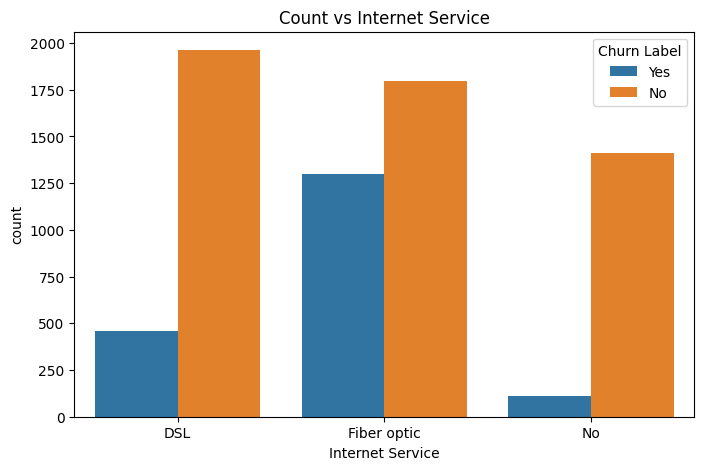

In [521]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Count vs Internet Service')
plt.show()

In [522]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

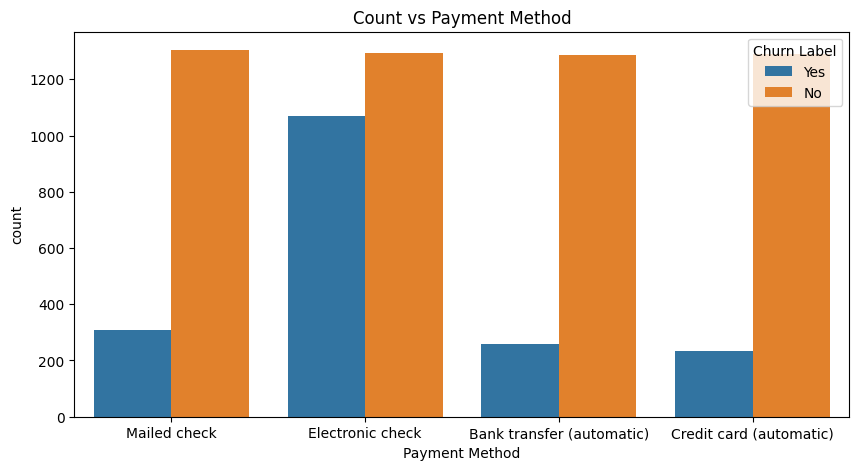

In [523]:
plt.figure(figsize=(10,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Count vs Payment Method')
plt.show()

In [524]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

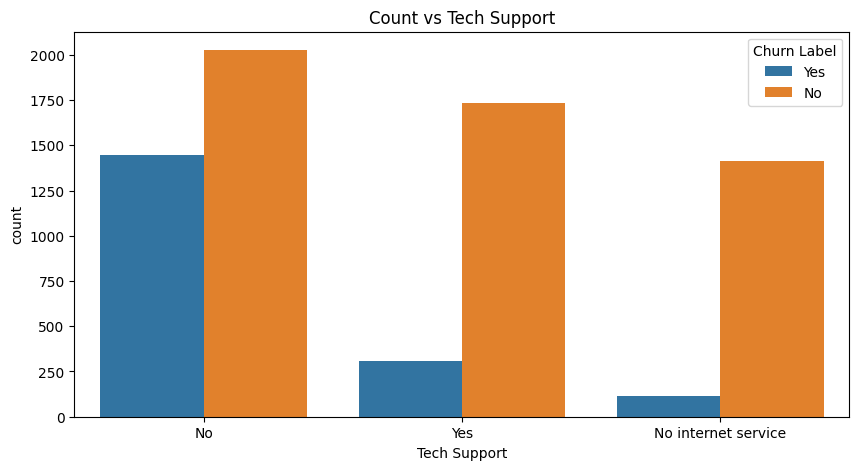

In [525]:
plt.figure(figsize=(10,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Count vs Tech Support')
plt.show()

In [526]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [527]:
avg_tenure

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [528]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [529]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
correlation_matrix=df[numerical_cols].corr()

In [530]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


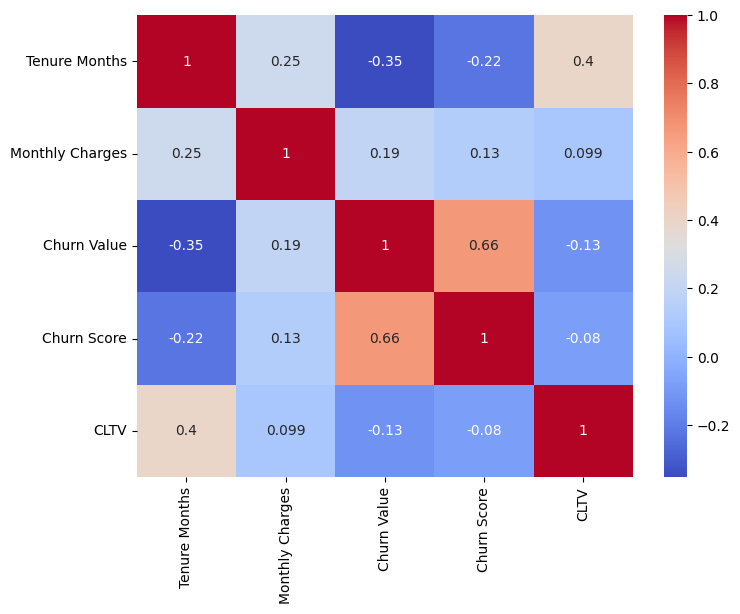

In [531]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [532]:
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


DATA CLEANING


In [533]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [534]:
df['Total Charges']

0        108.15
1        151.65
2         820.5
3       3046.05
4        5036.3
         ...   
7038     1419.4
7039     1990.5
7040     7362.9
7041     346.45
7042     6844.5
Name: Total Charges, Length: 7043, dtype: object

In [535]:
df['Total Charges']=pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].dtype

dtype('float64')

In [536]:
df['Total Charges']

0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64

In [537]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [538]:
df['Total Charges'].dtype

dtype('float64')

In [539]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [540]:
df[df['Total Charges'].isnull()]['Tenure Months']

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64

In [541]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [542]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [543]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [544]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']

In [545]:
df=df.drop(columns=drop_columns)

In [546]:
df.shape

(7043, 21)

In [547]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [548]:
print(df.columns.tolist())

['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


## Feature Engineering

Drop high-cardinality `City`. Add domain features before one-hot encoding.


In [549]:
internet_cols = [
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
]

df['Avg Monthly Spend'] = df['Total Charges'] / df['Tenure Months'].clip(lower=1)
df['Internet Add-ons'] = df[internet_cols].apply(lambda row: sum(v == 'Yes' for v in row), axis=1)
df['Auto Payment'] = df['Payment Method'].isin([
    'Bank transfer (automatic)', 'Credit card (automatic)',
]).astype(int)

contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract Ordinal'] = df['Contract'].map(contract_map)

df['Tenure Bucket'] = pd.cut(
    df['Tenure Months'],
    bins=[-1, 12, 36, 72],
    labels=['New', 'Mid', 'Loyal'],
)

# City has ~1,100 categories -> sparse noise, dropped before encoding
df = df.drop(columns=['City'])

print('Engineered features added. City dropped.')
print(df.columns.tolist())


Engineered features added. City dropped.
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Avg Monthly Spend', 'Internet Add-ons', 'Auto Payment', 'Contract Ordinal', 'Tenure Bucket']


In [550]:
# City removed before encoding (see feature engineering cell above).


In [551]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [552]:
df_encoded.shape

(7043, 37)

In [553]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Avg Monthly Spend,Internet Add-ons,Auto Payment,Contract Ordinal,Gender_Male,Senior Citizen_Yes,...,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Bucket_Mid,Tenure Bucket_Loyal
0,2,53.85,108.15,1,54.075000,2,0,0,True,False,...,False,False,False,False,True,False,False,True,False,False
1,2,70.70,151.65,1,75.825000,0,0,0,False,False,...,False,False,False,False,True,False,True,False,False,False
2,8,99.65,820.50,1,102.562500,3,0,0,False,False,...,False,True,False,False,True,False,True,False,False,False
3,28,104.80,3046.05,1,108.787500,4,0,0,False,False,...,False,True,False,False,True,False,True,False,True,False
4,49,103.70,5036.30,1,102.781633,4,1,0,True,False,...,False,True,False,False,True,False,False,False,False,True


In [554]:
# Encoding already excludes City.


In [555]:
print(df.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Avg Monthly Spend', 'Internet Add-ons', 'Auto Payment', 'Contract Ordinal', 'Tenure Bucket']


In [556]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Avg Monthly Spend,Internet Add-ons,Auto Payment,Contract Ordinal,Gender_Male,Senior Citizen_Yes,...,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Bucket_Mid,Tenure Bucket_Loyal
0,2,53.85,108.15,1,54.075000,2,0,0,True,False,...,False,False,False,False,True,False,False,True,False,False
1,2,70.70,151.65,1,75.825000,0,0,0,False,False,...,False,False,False,False,True,False,True,False,False,False
2,8,99.65,820.50,1,102.562500,3,0,0,False,False,...,False,True,False,False,True,False,True,False,False,False
3,28,104.80,3046.05,1,108.787500,4,0,0,False,False,...,False,True,False,False,True,False,True,False,True,False
4,49,103.70,5036.30,1,102.781633,4,1,0,True,False,...,False,True,False,False,True,False,False,False,False,True


In [557]:
df.shape

(7043, 25)

In [558]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Gender             7043 non-null   object  
 1   Senior Citizen     7043 non-null   object  
 2   Partner            7043 non-null   object  
 3   Dependents         7043 non-null   object  
 4   Tenure Months      7043 non-null   int64   
 5   Phone Service      7043 non-null   object  
 6   Multiple Lines     7043 non-null   object  
 7   Internet Service   7043 non-null   object  
 8   Online Security    7043 non-null   object  
 9   Online Backup      7043 non-null   object  
 10  Device Protection  7043 non-null   object  
 11  Tech Support       7043 non-null   object  
 12  Streaming TV       7043 non-null   object  
 13  Streaming Movies   7043 non-null   object  
 14  Contract           7043 non-null   object  
 15  Paperless Billing  7043 non-null   object  
 16  Paymen

In [559]:
df_encoded.shape

(7043, 37)

In [560]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Avg Monthly Spend,Internet Add-ons,Auto Payment,Contract Ordinal,Gender_Male,Senior Citizen_Yes,...,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Bucket_Mid,Tenure Bucket_Loyal
0,2,53.85,108.15,1,54.075000,2,0,0,True,False,...,False,False,False,False,True,False,False,True,False,False
1,2,70.70,151.65,1,75.825000,0,0,0,False,False,...,False,False,False,False,True,False,True,False,False,False
2,8,99.65,820.50,1,102.562500,3,0,0,False,False,...,False,True,False,False,True,False,True,False,False,False
3,28,104.80,3046.05,1,108.787500,4,0,0,False,False,...,False,True,False,False,True,False,True,False,True,False
4,49,103.70,5036.30,1,102.781633,4,1,0,True,False,...,False,True,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,19.713889,0,1,2,False,False,...,True,False,False,True,True,False,False,False,False,True
7039,24,84.80,1990.50,0,82.937500,5,0,1,True,False,...,False,True,True,False,True,False,False,True,True,False
7040,72,103.20,7362.90,0,102.262500,4,1,1,False,False,...,False,True,True,False,True,True,False,False,False,True
7041,11,29.60,346.45,0,31.495455,1,0,0,False,False,...,False,False,False,False,True,False,True,False,False,False


In [561]:
x=df_encoded.drop('Churn Value',axis=1)
y=df_encoded['Churn Value']

In [562]:
x.shape
y.shape

(7043,)

In [563]:
print(x)

      Tenure Months  Monthly Charges  Total Charges  Avg Monthly Spend  \
0                 2            53.85         108.15          54.075000   
1                 2            70.70         151.65          75.825000   
2                 8            99.65         820.50         102.562500   
3                28           104.80        3046.05         108.787500   
4                49           103.70        5036.30         102.781633   
...             ...              ...            ...                ...   
7038             72            21.15        1419.40          19.713889   
7039             24            84.80        1990.50          82.937500   
7040             72           103.20        7362.90         102.262500   
7041             11            29.60         346.45          31.495455   
7042             66           105.65        6844.50         103.704545   

      Internet Add-ons  Auto Payment  Contract Ordinal  Gender_Male  \
0                    2             0    

In [564]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


MACHINE LEARNING IMPLEMENTATION

In [565]:
from sklearn.model_selection import train_test_split

In [566]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y)


In [567]:
x_train.shape

(5634, 36)

In [568]:
x_test.shape

(1409, 36)

In [569]:
y_train.shape

(5634,)

In [570]:
y_test.shape

(1409,)

In [571]:
print(df.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Avg Monthly Spend', 'Internet Add-ons', 'Auto Payment', 'Contract Ordinal', 'Tenure Bucket']


In [572]:
from sklearn.ensemble import RandomForestClassifier


In [573]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [574]:
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [575]:
y_pred = rf_model.predict(x_test)

In [576]:
y_test

2196    0
3549    0
3515    0
5162    0
4642    0
       ..
5660    0
5150    0
4708    0
5381    0
6000    0
Name: Churn Value, Length: 1409, dtype: int64

In [577]:
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [578]:
from sklearn.metrics import accuracy_score

In [579]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.7899219304471257


In [580]:
from sklearn.metrics import confusion_matrix

In [581]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[920 115]
 [181 193]]


In [582]:
from sklearn.metrics import classification_report

In [583]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## Model Comparison

Compare algorithms on the same stratified train/test split. Optimize for churn recall.


In [584]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

comparison_rows = []
for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)[:, 1]
    comparison_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs),
    })

model_comparison = pd.DataFrame(comparison_rows).sort_values('Recall', ascending=False)
print(model_comparison.to_string(index=False))


/Users/rudranildatta/Desktop/cb_internship/churn-predictor/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              Model  Accuracy   Recall  Precision       F1  ROC-AUC
Logistic Regression  0.748048 0.796791   0.516464 0.626709 0.849154
  Gradient Boosting  0.800568 0.532086   0.652459 0.586156 0.852395
      Random Forest  0.787083 0.508021   0.620915 0.558824 0.837866


Approach 1- Handle Class Imbalance

In [585]:
rf_balanced=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

In [586]:
rf_balanced=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(x_train,y_train)
y_pred_balanced=rf_balanced.predict(x_test)
accuracy_balanced=accuracy_score(y_test,y_pred_balanced)
cm_balanced=confusion_matrix(y_test,y_pred_balanced)
print(accuracy_balanced)
print(cm_balanced)
print(classification_report(y_test,y_pred_balanced))


0.794180269694819
[[929 106]
 [184 190]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



Approach 2 Hyperparameter Tuning

Approach 2 — Hyperparameter Tuning (GridSearchCV on train only, no test leakage)


In [587]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12, None],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=1,
)
grid_rf.fit(x_train, y_train)

print('Best params (CV recall):', grid_rf.best_params_)
print('Best CV recall:', round(grid_rf.best_score_, 3))

rf_tuned = grid_rf.best_estimator_
y_pred_tuned = rf_tuned.predict(x_test)
y_prob_tuned = rf_tuned.predict_proba(x_test)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print('Test accuracy:', round(accuracy_tuned, 3))
print(cm_tuned)
print(classification_report(y_test, y_pred_tuned))
print('Test ROC-AUC:', round(roc_auc_score(y_test, y_prob_tuned), 3))


Best params (CV recall): {'max_depth': 8, 'n_estimators': 100}
Best CV recall: 0.786
Test accuracy: 0.769
[[794 241]
 [ 84 290]]
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.55      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

Test ROC-AUC: 0.853


In [588]:
# city_cols = [col for col in x.columns if col.startswith('City_')]

# x = x.drop(columns=city_cols)

In [589]:
# [col for col in x.columns if col.startswith('City_')]

Approach 3 - Feature Importance Analysis

In [590]:
import pandas as pd

# Create the feature_importance DataFrame with all features first
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_tuned.feature_importances_
})

# Filter out city-related features
feature_importance = feature_importance[~feature_importance['Feature'].str.startswith('City_')]

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

                                   Feature  Importance
6                         Contract Ordinal    0.147439
0                            Tenure Months    0.130444
14            Internet Service_Fiber optic    0.087354
2                            Total Charges    0.083666
29                       Contract_Two year    0.075187
10                          Dependents_Yes    0.070982
3                        Avg Monthly Spend    0.057420
1                          Monthly Charges    0.052282
32         Payment Method_Electronic check    0.036629
35                     Tenure Bucket_Loyal    0.035614
28                       Contract_One year    0.022716
18       Online Backup_No internet service    0.018170
26    Streaming Movies_No internet service    0.014616
4                         Internet Add-ons    0.014148
23                        Tech Support_Yes    0.012681
22        Tech Support_No internet service    0.012581
17                     Online Security_Yes    0.012387
16     Onl

In [591]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_tuned.feature_importances_,
}).sort_values('Importance', ascending=False)

print(feature_importance.head(15))


                                 Feature  Importance
6                       Contract Ordinal    0.147439
0                          Tenure Months    0.130444
14          Internet Service_Fiber optic    0.087354
2                          Total Charges    0.083666
29                     Contract_Two year    0.075187
10                        Dependents_Yes    0.070982
3                      Avg Monthly Spend    0.057420
1                        Monthly Charges    0.052282
32       Payment Method_Electronic check    0.036629
35                   Tenure Bucket_Loyal    0.035614
28                     Contract_One year    0.022716
18     Online Backup_No internet service    0.018170
26  Streaming Movies_No internet service    0.014616
4                       Internet Add-ons    0.014148
23                      Tech Support_Yes    0.012681


In [592]:
print(df.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Avg Monthly Spend', 'Internet Add-ons', 'Auto Payment', 'Contract Ordinal', 'Tenure Bucket']


In [593]:
print(x.columns.tolist())

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Avg Monthly Spend', 'Internet Add-ons', 'Auto Payment', 'Contract Ordinal', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check', 'Tenure Bucket_Mid', 'Tenure Bucket_Loyal']


In [594]:
#[col for col in x.columns if col.startswith('City_')]

In [595]:
#[col for col in x.columns if col.startswith('City_')][:20]

In [596]:
print(feature_importance. tail(15))

                                   Feature  Importance
20   Device Protection_No internet service    0.007758
15                     Internet Service_No    0.007667
9                              Partner_Yes    0.007464
7                              Gender_Male    0.006810
25                        Streaming TV_Yes    0.005806
27                    Streaming Movies_Yes    0.005774
19                       Online Backup_Yes    0.005730
13                      Multiple Lines_Yes    0.005496
8                       Senior Citizen_Yes    0.004937
33             Payment Method_Mailed check    0.004747
31  Payment Method_Credit card (automatic)    0.004426
24        Streaming TV_No internet service    0.003857
21                   Device Protection_Yes    0.003345
11                       Phone Service_Yes    0.002431
12         Multiple Lines_No phone service    0.001987


In [597]:
x_selected=x.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'],axis=1)

In [598]:
x_train_selected, x_test_selected, y_train, y_test=train_test_split(x_selected,y,test_size=0.2,random_state=42)


In [599]:
rf_selected=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_selected.fit(x_train_selected,y_train)
y_pred_selected=rf_selected.predict(x_test_selected)
accuracy_selected=accuracy_score(y_test,y_pred_selected)
print(classification_report(y_test,y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1009
           1       0.59      0.74      0.65       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.78      1409



Approach-combination of trees and depth


In [600]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [601]:
# Top GridSearchCV candidates on train CV (test set not used for selection)
cv_results = pd.DataFrame(grid_rf.cv_results_)
top_cv = cv_results.sort_values('mean_test_score', ascending=False)[
    ['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score']
].head(5)
print(top_cv)


   param_n_estimators param_max_depth  mean_test_score  std_test_score
0                 100               8         0.785953        0.019271
2                 300               8         0.781271        0.021941
1                 200               8         0.781271        0.021110
3                 100              10         0.738462        0.026283
4                 200              10         0.735786        0.028300


In [602]:
final_rf = rf_tuned


In [603]:
cv_accuracy=cross_val_score(final_rf,x_train,y_train,cv=5,scoring='accuracy')
cv_recall=cross_val_score(final_rf,x_train,y_train,cv=5,scoring='recall')

In [604]:
cv_accuracy

array([0.62555457, 0.64773736, 0.60070985, 0.64685004, 0.60479574])

In [605]:
cv_recall

array([0.2755102 , 0.19727891, 0.27210884, 0.23809524, 0.2559727 ])

In [606]:
cv_recall.mean()

np.float64(0.2477931787049291)

In [607]:
cv_accuracy.mean()

np.float64(0.6251295112222046)

In [608]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

## Threshold Tuning

Default 0.5 cutoff is arbitrary for imbalanced churn. Pick threshold from precision-recall on train CV probs.


In [609]:
from sklearn.metrics import precision_recall_curve

train_probs = rf_tuned.predict_proba(x_train)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, train_probs)

target_recall = 0.80
idx = int(np.argmin(np.abs(recalls[:-1] - target_recall)))
churn_threshold = float(thresholds[idx])

print(f'Selected churn threshold: {churn_threshold:.3f}')
print(f'Train recall at threshold: {recalls[idx]:.3f}')
print(f'Train precision at threshold: {precisions[idx]:.3f}')

y_pred_threshold = (y_prob_tuned >= churn_threshold).astype(int)
print('\nTest metrics at tuned threshold:')
print(classification_report(y_test, y_pred_threshold))


Selected churn threshold: 0.030
Train recall at threshold: 0.881
Train precision at threshold: 0.264

Test metrics at tuned threshold:
              precision    recall  f1-score   support

           0       0.74      0.13      0.22      1009
           1       0.29      0.89      0.43       400

    accuracy                           0.34      1409
   macro avg       0.52      0.51      0.33      1409
weighted avg       0.61      0.34      0.28      1409



In [610]:
y_prob=rf_tuned.predict_proba(x)

In [611]:
y_prob1=rf_tuned.predict_proba(x_test)

In [612]:
churn_probability=y_prob[:,1]

In [613]:
churn_prob=y_prob1[:,1]


In [614]:
fpr,tpr,thresholds=roc_curve(y_test,churn_prob)
auc_score=roc_auc_score(y_test,churn_prob)
print('AUC Score:',auc_score)

AUC Score: 0.5209848860257681


CUSTOMER SEGMENTATION

segmentation

In [615]:
segmentation_data=pd.DataFrame({'Tenure Months':x['Tenure Months'],
                                'Monthly charges':x['Monthly Charges'],
                                'Total Charges':x['Total Charges'],
                                'Churn probability':churn_probability})

In [616]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn probability
0,2,53.85,108.15,0.684520
1,2,70.70,151.65,0.743229
2,8,99.65,820.50,0.792226
3,28,104.80,3046.05,0.534144
4,49,103.70,5036.30,0.503565
...,...,...,...,...
7038,72,21.15,1419.40,0.012192
7039,24,84.80,1990.50,0.119905
7040,72,103.20,7362.90,0.100642
7041,11,29.60,346.45,0.433088


implementation of kmeans

In [617]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [618]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   0.99428604]
 [-1.23672422  0.19736523 -0.93887444  1.18910764]
 [-0.99240204  1.1595457  -0.64378925  1.35169926]
 [-0.17799476  1.33071079  0.3380854   0.49527284]
 [ 0.67713287  1.29415125  1.2161497   0.39379837]]


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

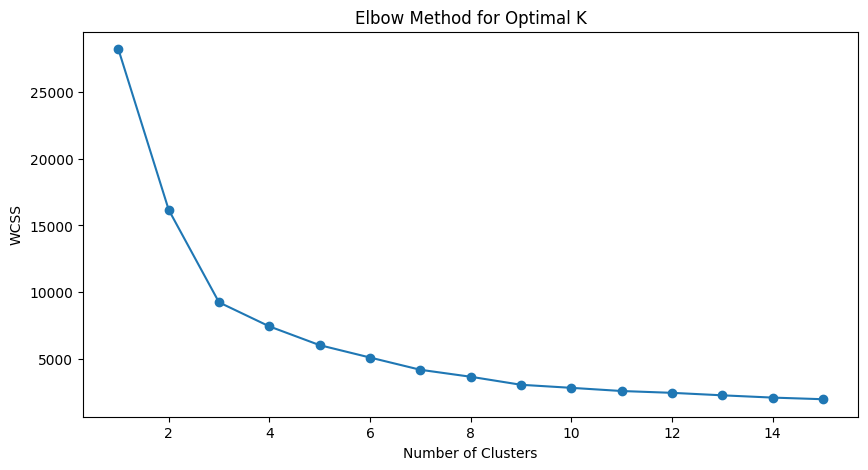

In [619]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16): #loop from 1 to 16
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(10,5))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [620]:
kmeans=KMeans(n_clusters=3, random_state=42)
#segmentation_data['Cluster']=kmeans.fit_predict(scaled_data)

In [621]:
clusters=kmeans.fit_predict(scaled_data)

In [622]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn probability
0,2,53.85,108.15,0.684520
1,2,70.70,151.65,0.743229
2,8,99.65,820.50,0.792226
3,28,104.80,3046.05,0.534144
4,49,103.70,5036.30,0.503565
...,...,...,...,...
7038,72,21.15,1419.40,0.012192
7039,24,84.80,1990.50,0.119905
7040,72,103.20,7362.90,0.100642
7041,11,29.60,346.45,0.433088


In [623]:
segmentation_data['Cluster']=clusters

In [624]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn probability,Cluster
0,2,53.85,108.15,0.684520,1
1,2,70.70,151.65,0.743229,1
2,8,99.65,820.50,0.792226,1
3,28,104.80,3046.05,0.534144,1
4,49,103.70,5036.30,0.503565,0
...,...,...,...,...,...
7038,72,21.15,1419.40,0.012192,2
7039,24,84.80,1990.50,0.119905,2
7040,72,103.20,7362.90,0.100642,0
7041,11,29.60,346.45,0.433088,2


In [625]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [626]:
cluster_summary

,Tenure Months,Monthly charges,Total Charges,Churn probability
Cluster,,,,
0,58.436125,90.719116,5295.240126,0.256195
1,10.658126,71.148107,856.785698,0.703335
2,32.841990,33.259515,1091.115648,0.141469


In [627]:
cluster_names={
    0:'budget loyal customer',
    1:'high risk new customer',
    2:'loyal premium customer'
}

In [628]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)

In [629]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.684520,1,high risk new customer
1,2,70.70,151.65,0.743229,1,high risk new customer
2,8,99.65,820.50,0.792226,1,high risk new customer
3,28,104.80,3046.05,0.534144,1,high risk new customer
4,49,103.70,5036.30,0.503565,0,budget loyal customer
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.012192,2,loyal premium customer
7039,24,84.80,1990.50,0.119905,2,loyal premium customer
7040,72,103.20,7362.90,0.100642,0,budget loyal customer
7041,11,29.60,346.45,0.433088,2,loyal premium customer


<Axes: xlabel='Tenure Months', ylabel='Monthly charges'>

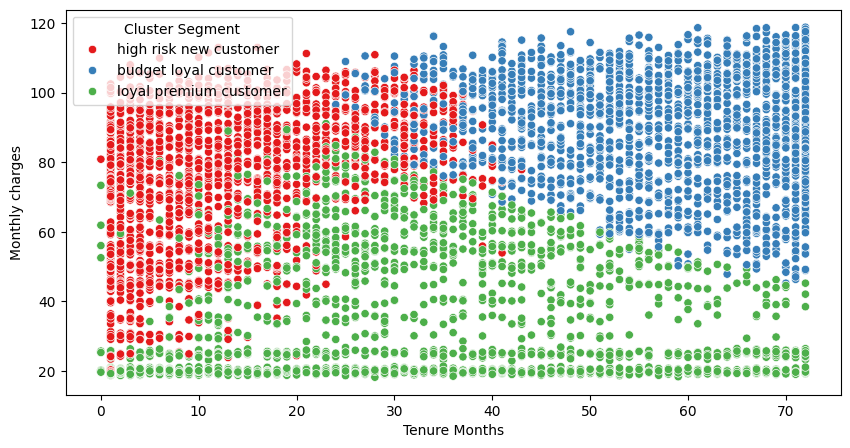

In [630]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Tenure Months', y='Monthly charges', hue='Cluster Segment', data=segmentation_data, palette='Set1')

<Axes: xlabel='Tenure Months', ylabel='Churn probability'>

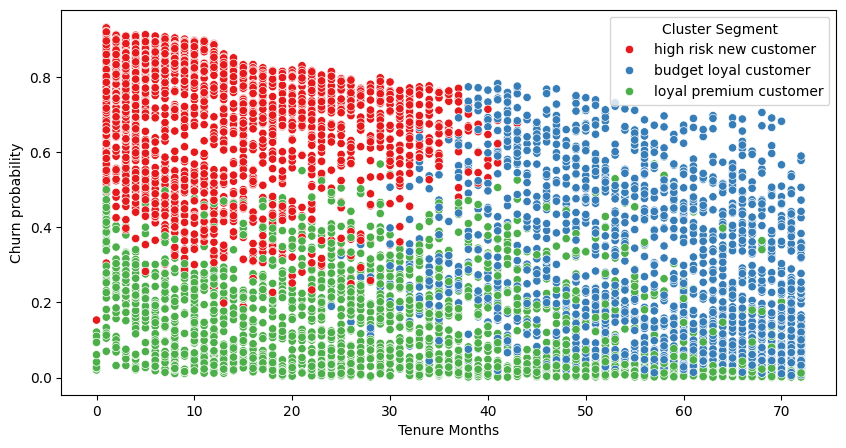

In [631]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Tenure Months', y='Churn probability', hue='Cluster Segment', data=segmentation_data, palette='Set1')

<Axes: xlabel='Total Charges', ylabel='Churn probability'>

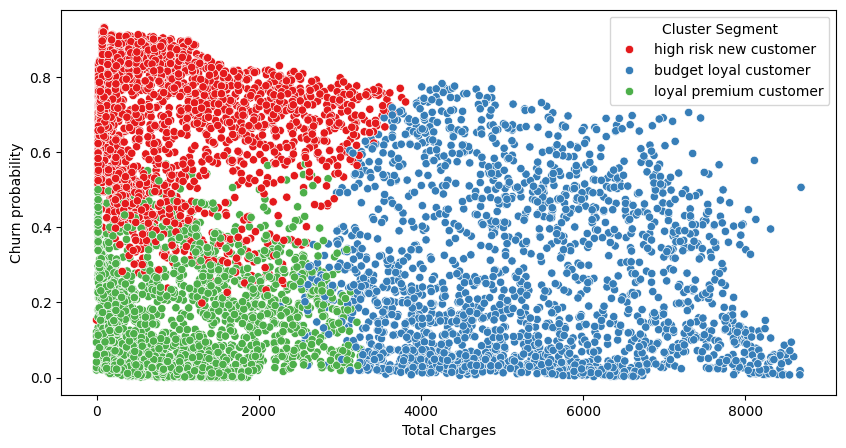

In [632]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Total Charges', y='Churn probability', hue='Cluster Segment', data=segmentation_data, palette='Set1')

<Axes: xlabel='Monthly charges', ylabel='Churn probability'>

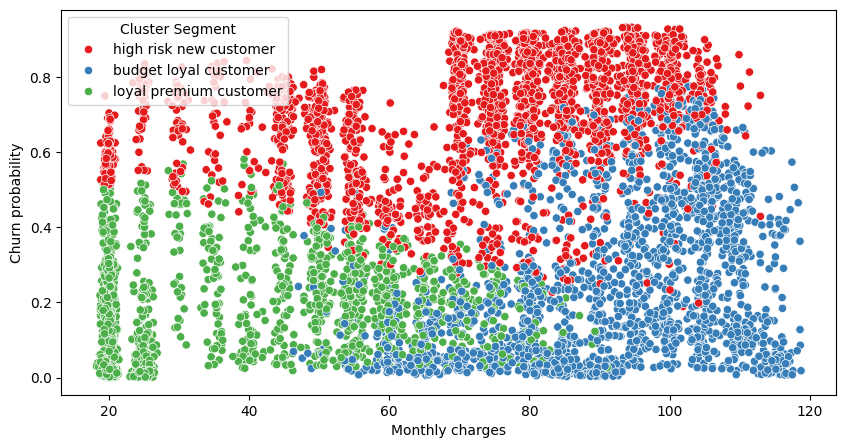

In [633]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Monthly charges', y='Churn probability', hue='Cluster Segment', data=segmentation_data, palette='Set1')

## Save Models for Deployment

Run this cell after training to export artifacts for the Streamlit app.

In [634]:
import os
import joblib

os.makedirs('models', exist_ok=True)

# Recompute threshold so save cell is safe even if run standalone
_train_probs = rf_final.predict_proba(x_train)[:, 1] if 'x_train' in globals() else rf_final.predict_proba(x)[:, 1]
_y_ref = y_train if 'y_train' in globals() else y
_p, _r, _t = precision_recall_curve(_y_ref, _train_probs)
churn_threshold = float(_t[int(np.argmin(np.abs(_r[:-1] - 0.80)))])


Saved models with best params: {'max_depth': 8, 'n_estimators': 100}
Churn threshold: 0.03
